In [1]:
import os
import numpy as np
import pandas as pd
import cvxpy as cp
from scipy.optimize import minimize
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import torch
from torch import nn

output_file         = '../05_output/'
osap_data           = '../03_data/osap/'
temp_dir            = "D:/github_repositories"

os.environ["TEMP"]                  = temp_dir
os.environ["TMP"]                   = temp_dir
os.environ["JOBLIB_TEMP_FOLDER"]    = temp_dir
os.environ['PYTHONWARNINGS']        = 'ignore'

d:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class portfolio_dataset(Dataset):
    """
    X: (n_stocks, n_time, n_features)
    y: (n_stocks, n_time, 1)  或 (n_stocks, n_time)

    返回:
        x_t: (n_stocks, n_features)
        y_t: (n_stocks, 1)
    """
    def __init__(self, X, y, dtype=torch.float32):
        X = torch.as_tensor(X, dtype=dtype)
        y = torch.as_tensor(y, dtype=dtype)

        if y.ndim == 2:
            y = y.unsqueeze(-1)

        assert X.ndim == 3, "X must be (stocks, time, features)"
        assert y.ndim == 3, "y must be (stocks, time, 1)"
        assert X.shape[0] == y.shape[0], "stock dimension mismatch"
        assert X.shape[1] == y.shape[1], "time dimension mismatch"

        self.X = X.permute(1, 0, 2).contiguous()
        self.y = y.permute(1, 0, 2).contiguous()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def create_dataloader(X, y, batch_size=60, shuffle=False, num_workers=0, drop_last=False):
    dataset = portfolio_dataset(X, y)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,   # 时间序列通常不要打乱
        num_workers=num_workers,
        drop_last=drop_last,
    )
    return dataset, loader


In [3]:
class cross_sectional_norm(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def forward(self, x):
        mean                = x.mean(dim=1, keepdim=True)
        std                 = x.std(dim=1,  keepdim=True)
        return (x-mean)/std

class deep_ppp_nn(nn.Module):
    def __init__(self, input_dim, hidden_dim=(32, 16, 8), dropout=0, neg_slope=0, max_weight=0.03):
        super().__init__()
        self.max_weight     = max_weight
        prev_dim            = input_dim
        self.layers         = nn.ModuleList()
        
        self.layers.append(nn.Dropout(dropout))
        for h in hidden_dim:
            self.layers.append(nn.Linear(prev_dim, h))
            self.layers.append(nn.LeakyReLU(neg_slope))
            self.layers.append(nn.Dropout(dropout))
            self.layers.append(cross_sectional_norm())
            prev_dim = h
        self.layers.append(nn.Linear(prev_dim, 1))

        self._init_weight()

    def _init_weight(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        # print('x is: ', x)
        T, N, L             = x.shape
        valid               = ~torch.isnan(x).all(dim=-1, keepdim=True)
        Nt                  = torch.sum(valid, dim=1, keepdim=True).expand(T, N, 1)
        x                   = torch.nan_to_num(x, nan=0, posinf=0, neginf=0)

        tilt = x
        for layer in self.layers:
            tilt = layer(tilt)
            
        # tilt                = torch.where(valid, tilt, torch.tensor(float('nan'), device=x.device))

        # normalize tilt
        tilt                = tilt*valid
        tilt_mean           = tilt.sum(dim=1, keepdim=True)/Nt
        tilt_demean         = tilt - tilt_mean
        tilt_std            = torch.sqrt((tilt_demean**2).sum(dim=1, keepdim=True)/Nt)
        tilt                = (tilt - tilt_mean)/(tilt_std + 1e-9)

        # calculate weight
        tilt                = tilt/Nt
        w                   = 1/Nt+tilt
        w                   = w*valid
        w                   = torch.where(valid, w, 0)

        return w
    


In [4]:
class crra_utility(nn.Module):
    def __init__(self, gamma = 5):
        super().__init__()
        self.gamma = gamma
    def forward(self, portfolio_ret):
        if np.abs(self.gamma - 1) <= 1e-6:
            utility = torch.log(1+portfolio_ret)
        else:
            utility = (1+portfolio_ret)**(1-self.gamma)/(1-self.gamma)

        loss = -utility.mean()
        return loss

In [20]:
class deep_ppp_trainer:
    def __init__(
        self, model, 
        device, 
        learning_rate = 0.01, 
        l1_penalty = 0, 
        gamma = 5, 
        utility_type = 'crra', 
        max_leverage = 1, 
        weight_constraint = 0.03,
    ):
        self.device             = device
        self.model              = model.to(self.device)
        self.learning_rate      = learning_rate
        self.l1_penalty         = l1_penalty
        self.gamma              = gamma
        self.utility_type       = utility_type
        self.max_leverage       = max_leverage
        self.weight_constraint  = weight_constraint
        self.patience_counter   = 0

        if self.utility_type == 'crra':
            self.utility_loss = crra_utility(self.gamma)

        self.utility_loss = self.utility_loss.to(self.device)

        self.optimizer          = optim.Adam(self.model.parameters(), lr=learning_rate)
        self.best_val_loss    = float('inf')
        self.best_model_weights = None

    def compute_portfolio_return(self, weights, ret):
        T, N, _ = ret.shape
        ret_median = ret.nanmedian(dim=1, keepdim=True).values
        # print(ret_median.expand(T, N, 1))
        
        ret = torch.where(ret == ret, ret, ret_median)
        ret = torch.nan_to_num(ret, nan=0, posinf=0, neginf=0)
        portfolio_return = (weights*ret).sum(dim=1).squeeze(-1)
        return portfolio_return
    
    def compute_leverage_penalty(self, weights):
        leverage = torch.relu(-weights).sum(dim=1).mean()
        leverage_loss = torch.relu(leverage - self.max_leverage)
        return leverage_loss
    
    def compute_l1_penalty(self,):
        l1_loss = 0
        for param in self.model.parameters():
            l1_loss = l1_loss + torch.abs(param).sum()
        return l1_loss
    
    def train_step(self, batch_x, batch_y):
        self.model.train()
        self.optimizer.zero_grad()

        batch_x = batch_x.to(self.device)
        batch_y = batch_y.to(self.device)

        weights = self.model(batch_x)
        portfolio_return = self.compute_portfolio_return(weights, batch_y)

        utility_loss = self.utility_loss(portfolio_return)
        l1_loss = self.compute_l1_penalty()
        leverage_loss = self.compute_leverage_penalty(weights)

        total_loss = utility_loss + self.l1_penalty*l1_loss + 10000*leverage_loss

        total_loss.backward()
        nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1)
        self.optimizer.step()

        return total_loss.item(), utility_loss.item()
    
    def val_step(self, batch_x, batch_y):
        self.model.eval()
        
        with torch.no_grad():
            batch_x = batch_x.to(self.device)
            batch_y = batch_y.to(self.device)

            weights = self.model(batch_x)
            portfolio_return = self.compute_portfolio_return(weights, batch_y)

            val_loss = self.utility_loss(portfolio_return)

        return val_loss.item(), portfolio_return

    def train_epoch(self, train_loader, val_loader=None, patience = 30):
        train_losses = []
        val_losses = []

        for batch_x, batch_y in train_loader:
            train_loss, _ = self.train_step(batch_x, batch_y)
            train_losses.append(train_loss)
        
        avg_train_loss = np.mean(train_loss)

        if val_loader is not None:
            for batch_x, batch_y in val_loader:
                val_loss, _ = self.val_step(batch_x, batch_y)
                val_losses.append(val_loss)
            
            avg_val_loss = np.mean(val_losses)
            
            if avg_val_loss > self.best_val_loss:
                self.best_val_loss = avg_val_loss
                self.patience_counter = 0
                self.best_model_weights = {
                    k: v.clone() for k, v in self.model.state_dict().items()
                }
            else:
                self.patience_counter += 1
                if self.patience_counter >= patience:
                    self.model.load_state_dict(self.best_model_weights)
                    return train_losses, val_losses, True
        
        return train_losses, val_losses, False
    
    def fit(self, train_loader, val_loader=None, epochs=200, patience=30, verbose=10):
        all_train_losses = []
        all_val_losses = []
        
        for epoch in range(epochs):
            train_losses, val_losses, early_stop = self.train_epoch(
                train_loader, val_loader, patience
            )
            
            all_train_losses.append(np.mean(train_losses))
            all_val_losses.append(np.mean(val_losses))
            
            if (epoch + 1) % verbose == 0:
                avg_train = np.mean(train_losses)
                msg = f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train:.6f}"
                if val_loader is not None:
                    avg_val = np.mean(val_losses)
                    msg += f", Val Loss: {avg_val:.6f}"
                if verbose >= 5:
                    print(msg)
            
            if early_stop:
                break
        return all_train_losses, all_val_losses

In [6]:
signalnames         = np.load(osap_data + 'signalnames.npy', allow_pickle=True)
date                = np.load(osap_data + 'date.npy')
ret                 = np.load(osap_data + 'ret.npy')
signals             = np.load(osap_data + 'signals.npy')

In [7]:
train_ret           = ret[:, :240]
train_signals       = signals[:, :240, :]
val_ret             = ret[:, 240:300]
val_signals         = signals[:, 240:300, :]
_, train_loader     = create_dataloader(train_signals, train_ret)
_, val_loader       = create_dataloader(val_signals, val_ret, batch_size=30)

In [21]:
model = deep_ppp_nn(
    input_dim=train_signals.shape[-1], 
    hidden_dim=(32, 16, 8), 
    dropout=0, 
    neg_slope=0.01, 
    max_weight=0.03
)
trainer = deep_ppp_trainer(
    model=model,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    learning_rate=0.01,
    l1_penalty=1e-3,
    gamma=5,
    utility_type='crra',
    max_leverage=1,
    weight_constraint=0.03,
)
train_loss, val_loss = trainer.fit(train_loader, val_loader, epochs=200, patience=30, verbose=10)

## 计算loss的时候没有把invalid的数据排除，导致数字偏小

Epoch 10/200, Train Loss: 0.284247, Val Loss: 0.234511
Epoch 20/200, Train Loss: 0.259208, Val Loss: 0.234457


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

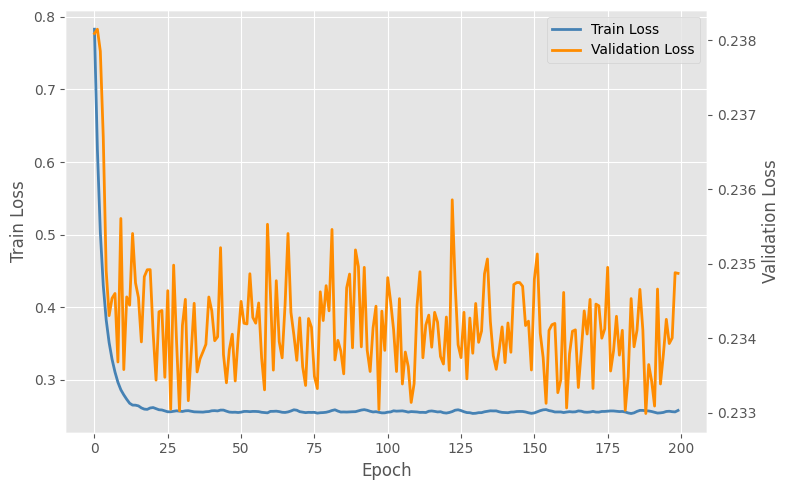

In [19]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')
fig, ax1 = plt.subplots(figsize=(8, 5))

# 绘制曲线并保存对象用于合并图例
lns1 = ax1.plot(train_loss, label='Train Loss', color='steelblue', lw=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss')

ax2 = ax1.twinx()
lns2 = ax2.plot(val_loss, label='Validation Loss', color='darkorange', lw=2)
ax2.set_ylabel('Validation Loss')
ax2.grid(False) # 通常双轴只保留一个轴的网格，否则画面太乱

# 合并两个轴的图例
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
def equal_weight(ret, size):
    N, T            = ret.shape
    valid           = ~np.isnan(ret) & ~np.any(np.isnan(size), axis=2)
    Nt              = np.sum(valid, axis=0, keepdims=True)
    Nt_mat          = np.tile(Nt, (N, 1))
    weight          = np.where(valid, 1/Nt_mat, np.nan)
    return weight

def value_weight(ret, size):
    me              = size[:, :] 
    valid           = ~np.isnan(ret) & ~np.isnan(me)
    me              = np.where(valid, me, 0)
    totme           = np.sum(me, axis=0, keepdims=True)
    weight          = np.where(valid, me/totme, np.nan)
    return weight

def ppp_port(ret, signals, delta, gamma, p):
    def utilityf(rp, gamma):
        if gamma == 1:
            return cp.log(1+rp)
        else:
            return cp.power(1+rp, 1-gamma)/(1-gamma)
    
    N, T, L         = signals.shape
    valid           = ~np.isnan(ret) & ~np.any(np.isnan(signals), axis=2)
    Nt              = np.sum(valid, axis=0, keepdims=True)
    Nt_mat          = np.tile(Nt, (N, 1))

    signals         = np.where(valid[:, :, np.newaxis], signals, 0.0)
    ret             = np.where(valid, ret, 0.0)

    theta           = cp.Variable((L, 1))
    w               = cp.multiply(cp.squeeze(signals.transpose((1, 0, 2)) @ theta, axis=2), 1/Nt_mat.T) + valid.T/Nt_mat.T
    rp              = cp.sum(cp.multiply(w, ret.transpose(1, 0)), axis=1)
    u               = utilityf(rp, gamma)

    objective       = cp.Minimize(- cp.mean(u) + delta*cp.norm(theta, p))
    # constraints = [w >= 0]
    prob            = cp.Problem(objective)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    
    return theta.value.reshape(-1, 1)

In [ ]:
def _single_step(i, ret, signals, size, train_len, port_num, strategy_num, use_chars, p, s):
    rng                 = np.random.default_rng(45 + s)
    train_ret           = ret[:, :i+train_len]
    train_signals       = signals[:, :i+train_len, :]
    # train_signals       = (train_signals - np.nanmean(train_signals, axis=0, keepdims=True))/np.nanstd(train_signals, axis=0, keepdims=True)

    test_ret            = ret[:, i+train_len:i+train_len+1]
    test_chars          = signals[:, i+train_len:i+train_len+1, :]
    test_size           = size[:, i+train_len:i+train_len+1]
    valid               = (~np.isnan(test_ret) & ~np.any(np.isnan(test_chars), axis=2))
    
    if np.sum(valid) > port_num and port_num != -1:
        valid_idx           = np.where(valid.flatten())[0]
        idx                 = rng.permutation(valid_idx)[:port_num]
        new_valid           = np.zeros_like(valid)
        new_valid[idx, :]   = 1
    else:
        new_valid           = valid

    test_ret            = np.where(new_valid, test_ret, np.nan)
    test_chars          = np.where(np.tile(new_valid[:, :, np.newaxis], (1, 1, signals.shape[2])), test_chars, np.nan)
    test_chars          = (test_chars - np.nanmean(test_chars, axis=0, keepdims=True))/np.nanstd(test_chars, axis=0, keepdims=True)

    wlist = []

    # equal weight
    weight_e            = equal_weight(test_ret, test_size)

    # value weight
    weight_v            = value_weight(test_ret, test_size)

    # ppp weight
    theta               = ppp_port(train_ret, train_signals, delta=0, gamma=5, p=2)
    weight_ppp          = np.squeeze(test_chars @ theta, axis=2)*weight_e + weight_e

    weight_e            = np.where(new_valid, weight_e, 0)
    weight_v            = np.where(new_valid, weight_v, 0)
    weight_ppp          = np.where(new_valid, weight_ppp, 0)

    wlist.append(np.squeeze(weight_e, axis=1))
    wlist.append(np.squeeze(weight_v, axis=1))
    wlist.append(np.squeeze(weight_ppp, axis=1))
    
    test_ret           = np.where(new_valid, test_ret, 0)
    port_ret = np.full((strategy_num, 1), np.nan)
    for j, weight in enumerate(wlist):
        weight              = np.where(~np.isnan(weight), weight, 0)
        port_ret[j]         = (weight @ test_ret[:, :])
    
    return i, port_ret

def evaluate(ret, signals, size, train_len, port_num, strategy_num, use_chars=0, p=2, s=0, n_jobs=1):
    N, T, L             = signals.shape
    T_steps             = T-train_len-1
    with Parallel(n_jobs=n_jobs, prefer='processes') as parallel:
        warnings.filterwarnings('ignore')
        results = dict(parallel(
            delayed(_single_step)(i, ret, signals, size, train_len, port_num, strategy_num, use_chars, p, s) for i in tqdm(range(T_steps))
        ))

    port_ret            = np.full((strategy_num, T_steps), np.nan)
    for k, v in results.items():
        port_ret[:, k:k+1] = v

    return port_ret

In [ ]:
charslist           = np.where(np.isin(signalnames, ['BM', 'Size', 'Mom12m']))[0]
sizelist            = np.where(np.isin(signalnames, ['Size']))[0][0]
port_ret            = evaluate(
                        ret[:, :, 0], 
                        signals[:, :, charslist], 
                        signals[:, :, sizelist], 
                        train_len=120, 
                        port_num=-1, 
                        strategy_num=3, 
                        use_chars=0, 
                        p=2, s=0, n_jobs=-1
                    )
results             = pd.DataFrame({
                        'mean':         np.round(np.mean(port_ret, axis=1)*12, 4), 
                        'std':          np.round(np.std(port_ret, axis=1)*np.sqrt(12), 4),
                        'sharpe ratio': np.round(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)), 4),
                    }, index=['equal weited', 'value weighted', 'ppp'])
results

In [ ]:
def plot_cumulative_returns(x_axis, *return_series):
    plt.figure(figsize=(10, 6))
    x_date = pd.to_datetime(x_axis, format='%Y%m', errors='coerce')
    
    for i, series in enumerate(return_series, start=1):
        series = np.asarray(series, dtype=float)
        cumulative = np.cumsum(np.log(1 + series))
        
        plt.plot(x_date, cumulative, label=f"Series {i}")
    
    # 自动调整日期标签的倾斜度，防止重叠
    plt.gcf().autofmt_xdate()
    
    plt.xlabel("Time (Year-Month)")
    plt.ylabel("Cumulative Return (Log)")
    plt.title("Cumulative Return Curves")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_cumulative_returns(date[121:], port_ret[0], port_ret[1], port_ret[2])

In [ ]:
charslist           = np.where(np.isin(signalnames, ['BM', 'Size', 'Mom12m']))[0]
sizelist            = np.where(np.isin(signalnames, ['Size']))[0][0]
start_date          = np.where(np.isin(date, [199101]))[0][0]

sharpe_ratio        = []
for port_num in range(100, 1501, 100):
    port_ret            = evaluate(
                            ret[:, start_date:, 0], 
                            signals[:, start_date:, charslist], 
                            signals[:, :, sizelist], 
                            train_len=120, 
                            port_num=port_num, 
                            strategy_num=3, 
                            use_chars=0, 
                            p=2, s=0, n_jobs=-1
                        )
    sharpe_ratio.append(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)))


In [ ]:
for port_num in range(1500, 2501, 100):
    port_ret            = evaluate(
                            ret[:, start_date:, 0], 
                            signals[:, start_date:, charslist], 
                            signals[:, :, sizelist], 
                            train_len=120, 
                            port_num=port_num, 
                            strategy_num=3, 
                            use_chars=0, 
                            p=2, s=0, n_jobs=-1
                        )
    sharpe_ratio.append(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(100, 1301, 100) / 120

plt.figure(figsize=(10, 5))
plt.plot(x, sharpe_ratio[:13], marker='o', markersize=4, linewidth=1.8)
plt.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
plt.xticks(x, rotation=45, fontsize=8)
plt.xlabel('Port Num / 120')
plt.ylabel('Sharpe Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()